# Notebook D — Analysis: % of Teacher + Graphs

Loads all judge results, computes mean scores per method × per size,
compares against teacher baseline, and generates publication-ready plots.

**Outputs:**
- Per-metric tables (absolute scores)
- Per-metric tables (% of teacher)
- Bar chart: composite_5 by method × size
- Line plot: % of teacher across all metrics
- Heatmap: reasoning metrics per method × size

In [1]:
# Cell 0: Config + load all judge data
import os, json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROJECT_DIR = r"C:\Users\adishalit1\Desktop\kd_project"
# PROJECT_DIR = os.path.expanduser("~/kd_project")  # Linux

DATA_DIR = os.path.join(PROJECT_DIR, "data")
N_EVAL = 100

METHODS = {
    "E1 WSFT":          "e1_wsft_adapted",
    "E5b Expl Entropy": "e5b_explanation_entropy_sft",
    "E7 Dec Only":      "e7_decision_only_sft",
    "E3 CW-WSFT":       "e3_cwwsft_adapted",
    "M3 Juggler":       "m3_juggler",
    "M7 Warmstart":     "m7_warmstart_from_e7",
    "M2v2 EWD":         "m2v2_EWD",
    "M2v2 WED":         "m2v2_WED",
    "M2v2 WDE":         "m2v2_WDE",
    "M2v2 EDW":         "m2v2_EDW",
    "M3v2 Juggler":     "m3v2_juggler",
    "Raw baseline":     "raw_baseline",
}

metric_cols = ["decision_accuracy","safety_score","clinical_correctness",
               "completeness","coherence","format_compliance"]

# ── Load teacher scores ──
teacher_scores = {c: [] for c in metric_cols}
teacher_judge = os.path.join(DATA_DIR, f"judge__teacher__{N_EVAL}.jsonl")
if os.path.exists(teacher_judge):
    for line in open(teacher_judge):
        try: obj = json.loads(line)
        except: continue
        if obj.get("status") == "ok" and "teacher" in obj.get("scores", {}):
            sc = obj["scores"]["teacher"]
            for c in metric_cols:
                if c in sc:
                    teacher_scores[c].append(float(sc[c]))

teacher_mean = {c: np.mean(v) if v else 0.0 for c, v in teacher_scores.items()}
print("Teacher means:")
for c, v in teacher_mean.items():
    print(f"  {c:25s}: {v:.3f}")

# ── Load method scores ──
all_rows = []
for display, stub in METHODS.items():
    judge_file = os.path.join(DATA_DIR, f"judge__{stub}__{N_EVAL}.jsonl")
    if not os.path.exists(judge_file):
        print(f"  ⏩ {display}: no judge file")
        continue

    n_ok = 0
    for line in open(judge_file):
        try: obj = json.loads(line)
        except: continue
        if obj.get("status") != "ok": continue
        n_ok += 1
        for mn, sc in obj.get("scores", {}).items():
            if isinstance(sc, dict):
                rec = {"method": display, "stub": stub, "model": mn}
                for c in metric_cols:
                    if c in sc:
                        rec[c] = float(sc[c])
                all_rows.append(rec)
    print(f"  ✅ {display}: {n_ok} ok records")

df = pd.DataFrame(all_rows)
print(f"\nTotal method score rows: {len(df)}")

Teacher means:
  decision_accuracy        : 4.350
  safety_score             : 4.240
  clinical_correctness     : 4.220
  completeness             : 3.130
  coherence                : 3.650
  format_compliance        : 3.660
  ⏩ E1 WSFT: no judge file
  ⏩ E5b Expl Entropy: no judge file
  ⏩ E7 Dec Only: no judge file
  ⏩ E3 CW-WSFT: no judge file
  ✅ M3 Juggler: 98 ok records
  ✅ M7 Warmstart: 100 ok records
  ✅ M2v2 EWD: 99 ok records
  ✅ M2v2 WED: 99 ok records
  ✅ M2v2 WDE: 100 ok records
  ✅ M2v2 EDW: 99 ok records
  ✅ M3v2 Juggler: 98 ok records
  ✅ Raw baseline: 100 ok records

Total method score rows: 2279


In [3]:
from IPython.display import display

# Cell 1: Per method × size aggregation
# Map raw model names to clean size labels
SIZE_MAP = {
    "qwen25_1p5b_base": "1.5B",
    "qwen25_3b_base":   "3B",
    "qwen25_7b_base":   "7B",
}
df["size"] = df["model"].map(SIZE_MAP).fillna(df["model"])

# Absolute scores
agg = df.groupby(["method","size"])[metric_cols].mean().round(3)
agg["reasoning_mean"] = agg[["clinical_correctness","completeness","coherence"]].mean(axis=1).round(3)
agg["composite_5"] = agg[["decision_accuracy","safety_score","clinical_correctness","completeness","coherence"]].mean(axis=1).round(3)

print("="*70)
print("  ABSOLUTE SCORES — method × size")
print("="*70)
display(agg)

# ── % of teacher ──
pct_df = agg.copy()
for c in metric_cols:
    if teacher_mean[c] > 0:
        pct_df[c] = (agg[c] / teacher_mean[c] * 100).round(1)
    else:
        pct_df[c] = np.nan
pct_df["reasoning_mean"] = pct_df[["clinical_correctness","completeness","coherence"]].mean(axis=1).round(1)
teacher_comp5 = np.mean([teacher_mean[c] for c in ["decision_accuracy","safety_score","clinical_correctness","completeness","coherence"]])
pct_df["composite_5"] = (agg["composite_5"] / teacher_comp5 * 100).round(1)

print("\n")
print("="*70)
print("  % OF TEACHER — method × size")
print("="*70)
display(pct_df)

  ABSOLUTE SCORES — method × size


decision_accuracy  safety_score  clinical_correctness  \
method       size                                                          
M2v2 EDW     1.5B              3.990         2.667                 1.313   
             3B                4.192         2.949                 1.758   
             7B                4.293         3.646                 2.646   
M2v2 EWD     1.5B              4.091         2.798                 1.455   
             3B                4.192         3.222                 1.869   
             7B                4.242         3.646                 2.687   
M2v2 WDE     1.5B              4.050         2.670                 1.190   
             3B                4.250         3.090                 1.730   
             7B                4.250         3.510                 2.380   
M2v2 WED     1.5B              4.040         2.657                 1.364   
             3B                4.091         3.071                 1.798   
             7B                4.293         3.697                 2.778   
M3 Juggler   1.5B              3.980         2.449                 1.214   
             3B                4.286         2.990                 1.765   
             7B                4.031         3.347                 2.429   
M3v2 Juggler 1.5B              3.878         2.439                 0.980   
             3B                4.031         3.031                 1.571   
             7B                4.031         3.398                 2.347   
M7 Warmstart 1.5B              3.600         2.760                 1.500   
             3B                4.100         3.300                 2.140   
Raw baseline 1.5B              2.900         1.870                 0.690   
             3B                3.650         2.850                 1.910   
             7B                4.150         3.360                 2.390   

                   completeness  coherence  format_compliance  reasoning_mean  \
method       size                                                               
M2v2 EDW     1.5B         2.566      3.475              4.970           2.451   
             3B           2.879      3.818              4.980           2.818   
             7B           3.455      4.323              4.980           3.475   
M2v2 EWD     1.5B         2.525      3.667              5.000           2.549   
             3B           2.758      3.939              5.000           2.855   
             7B           3.364      4.414              4.990           3.488   
M2v2 WDE     1.5B         2.470      3.570              4.960           2.410   
             3B           2.890      3.830              4.990           2.817   
             7B           3.330      4.210              4.990           3.307   
M2v2 WED     1.5B         2.576      3.667              5.000           2.536   
             3B           2.848      3.909              4.990           2.852   
             7B           3.475      4.364              4.960           3.539   
M3 Juggler   1.5B         2.347      3.490              4.959           2.350   
             3B           2.714      3.929              4.980           2.803   
             7B           3.204      4.235              4.969           3.289   
M3v2 Juggler 1.5B         2.194      3.224              4.969           2.133   
             3B           2.582      3.735              4.969           2.629   
             7B           3.122      4.214              4.990           3.228   
M7 Warmstart 1.5B         2.390      3.550              4.980           2.480   
             3B           2.970      4.000              4.970           3.037   
Raw baseline 1.5B         1.850      2.880              1.120           1.807   
             3B           2.390      3.590              3.100           2.630   
             7B           2.770      4.090              2.480           3.083   

                   composite_5  
method       size               
M2v2 EDW     1.5B        2



  % OF TEACHER — method × size


decision_accuracy  safety_score  clinical_correctness  \
method       size                                                          
M2v2 EDW     1.5B               91.7          62.9                  31.1   
             3B                 96.4          69.6                  41.7   
             7B                 98.7          86.0                  62.7   
M2v2 EWD     1.5B               94.0          66.0                  34.5   
             3B                 96.4          76.0                  44.3   
             7B                 97.5          86.0                  63.7   
M2v2 WDE     1.5B               93.1          63.0                  28.2   
             3B                 97.7          72.9                  41.0   
             7B                 97.7          82.8                  56.4   
M2v2 WED     1.5B               92.9          62.7                  32.3   
             3B                 94.0          72.4                  42.6   
             7B                 98.7          87.2                  65.8   
M3 Juggler   1.5B               91.5          57.8                  28.8   
             3B                 98.5          70.5                  41.8   
             7B                 92.7          78.9                  57.6   
M3v2 Juggler 1.5B               89.1          57.5                  23.2   
             3B                 92.7          71.5                  37.2   
             7B                 92.7          80.1                  55.6   
M7 Warmstart 1.5B               82.8          65.1                  35.5   
             3B                 94.3          77.8                  50.7   
Raw baseline 1.5B               66.7          44.1                  16.4   
             3B                 83.9          67.2                  45.3   
             7B                 95.4          79.2                  56.6   

                   completeness  coherence  format_compliance  reasoning_mean  \
method       size                                                               
M2v2 EDW     1.5B          82.0       95.2              135.8            69.4   
             3B            92.0      104.6              136.1            79.4   
             7B           110.4      118.4              136.1            97.2   
M2v2 EWD     1.5B          80.7      100.5              136.6            71.9   
             3B            88.1      107.9              136.6            80.1   
             7B           107.5      120.9              136.3            97.4   
M2v2 WDE     1.5B          78.9       97.8              135.5            68.3   
             3B            92.3      104.9              136.3            79.4   
             7B           106.4      115.3              136.3            92.7   
M2v2 WED     1.5B          82.3      100.5              136.6            71.7   
             3B            91.0      107.1              136.3            80.2   
             7B           111.0      119.6              135.5            98.8   
M3 Juggler   1.5B          75.0       95.6              135.5            66.5   
             3B            86.7      107.6              136.1            78.7   
             7B           102.4      116.0              135.8            92.0   
M3v2 Juggler 1.5B          70.1       88.3              135.8            60.5   
             3B            82.5      102.3              135.8            74.0   
             7B            99.7      115.5              136.3            90.3   
M7 Warmstart 1.5B          76.4       97.3              136.1            69.7   
             3B            94.9      109.6              135.8            85.1   
Raw baseline 1.5B          59.1       78.9               30.6            51.5   
             3B            76.4       98.4               84.7            73.4   
             7B            88.5      112.1               67.8            85.7   

                   composite_5  
method       size               
M2v2 EDW     1.5B         

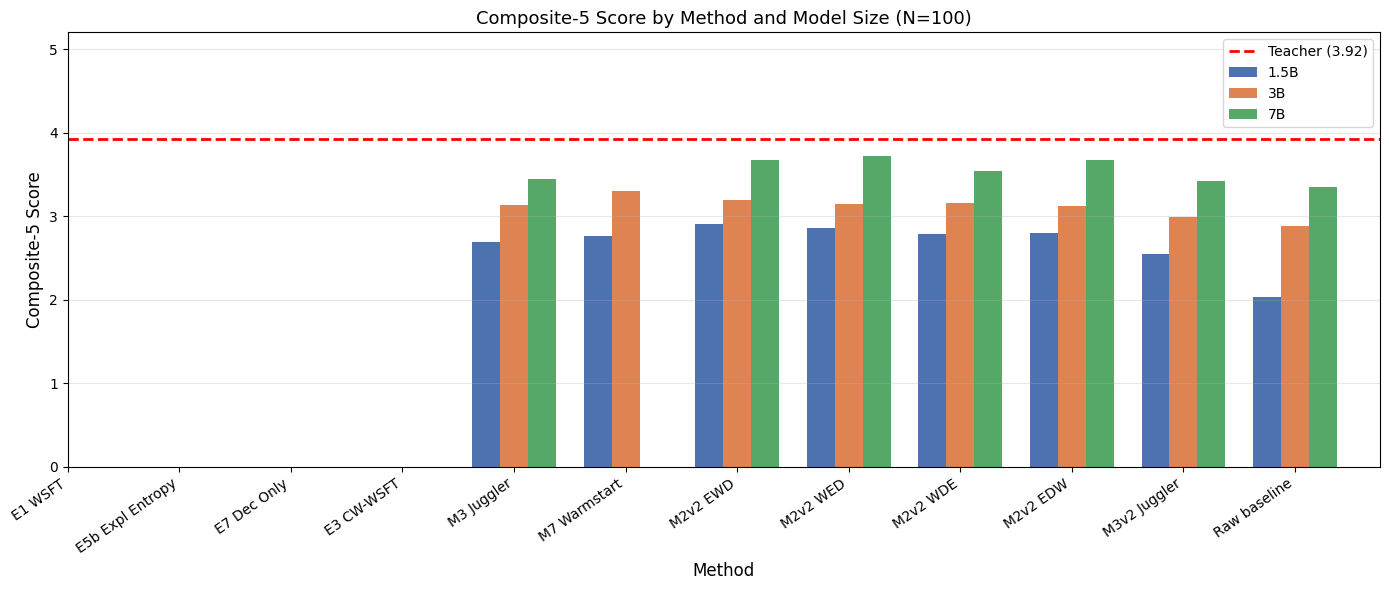

Saved: plot_composite5_by_method_size.png


In [4]:
# Cell 2: Headline plot — composite_5 by method × size
fig, ax = plt.subplots(figsize=(14, 6))

methods_list = list(METHODS.keys())
sizes = ["1.5B", "3B", "7B"]
x = np.arange(len(methods_list))
width = 0.25
colors = {"1.5B": "#4C72B0", "3B": "#DD8452", "7B": "#55A868"}

for i, size in enumerate(sizes):
    values = []
    for m in methods_list:
        try:
            values.append(agg.loc[(m, size), "composite_5"])
        except KeyError:
            values.append(np.nan)
    offset = (i - 1) * width
    ax.bar(x + offset, values, width, label=size, color=colors[size])

# Teacher reference line
ax.axhline(y=teacher_comp5, color="red", linestyle="--", linewidth=2,
           label=f"Teacher ({teacher_comp5:.2f})")

ax.set_xlabel("Method", fontsize=12)
ax.set_ylabel("Composite-5 Score", fontsize=12)
ax.set_title(f"Composite-5 Score by Method and Model Size (N={N_EVAL})", fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(methods_list, rotation=35, ha="right")
ax.legend(loc="upper right")
ax.grid(axis="y", alpha=0.3)
ax.set_ylim(0, 5.2)

plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, "plot_composite5_by_method_size.png"), dpi=150)
plt.show()
print("Saved: plot_composite5_by_method_size.png")

C:\Users\adishalit1\AppData\Local\Temp\ipykernel_24660\3910176602.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", len(method_order))
C:\Users\adishalit1\AppData\Local\Temp\ipykernel_24660\3910176602.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(metric_display, rotation=30, ha="right")


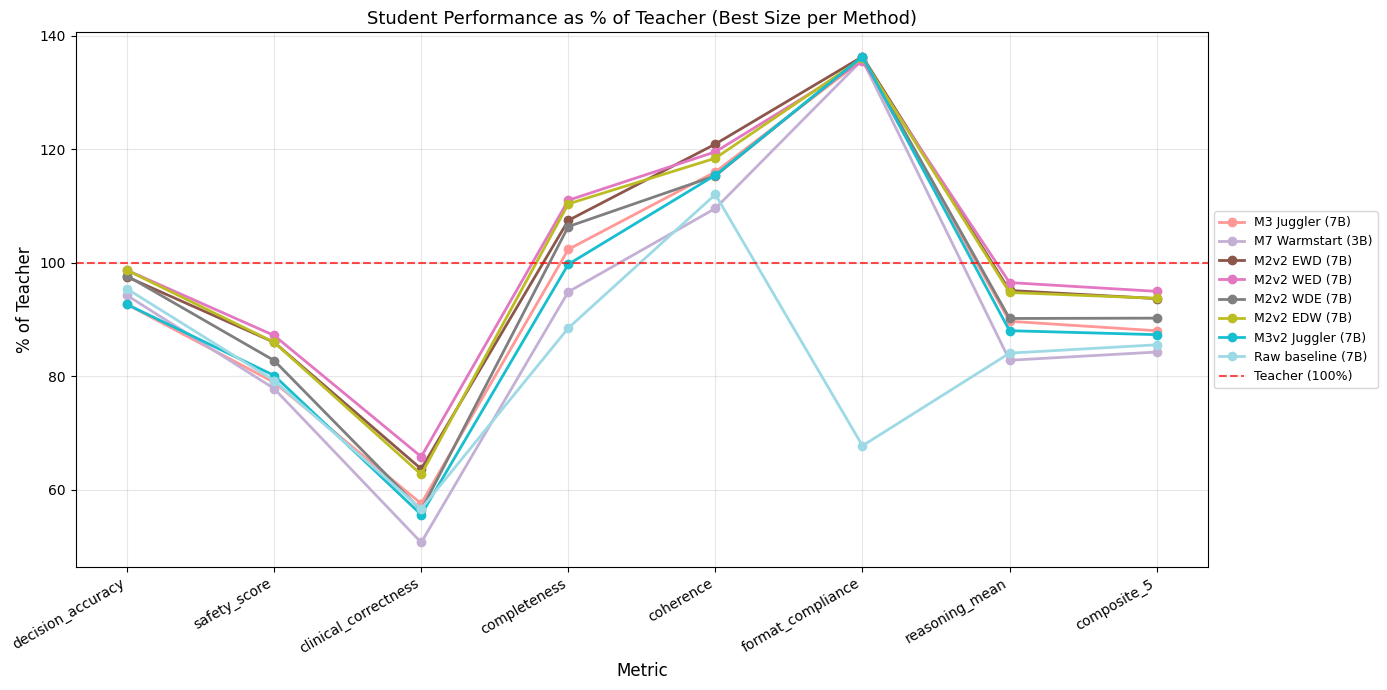

Saved: plot_pct_of_teacher.png


In [5]:
# Cell 3: % of teacher across all metrics
# One line per method, across metric names (x-axis), showing % of teacher
# Only show best size per method for clarity

fig, ax = plt.subplots(figsize=(14, 7))

# Find best composite_5 per method (picks the best size)
best_per_method = agg.reset_index().loc[
    agg.reset_index().groupby("method")["composite_5"].idxmax()
].set_index("method")

metric_display = ["decision_accuracy","safety_score","clinical_correctness",
                   "completeness","coherence","format_compliance","reasoning_mean","composite_5"]

method_order = list(METHODS.keys())
cmap = plt.cm.get_cmap("tab20", len(method_order))

for i, m in enumerate(method_order):
    if m not in best_per_method.index: continue
    row = best_per_method.loc[m]
    size_label = row["size"]
    vals = []
    for metric in metric_display:
        if metric in ("reasoning_mean", "composite_5"):
            # Compute teacher ref
            if metric == "reasoning_mean":
                t = np.mean([teacher_mean[c] for c in ["clinical_correctness","completeness","coherence"]])
            else:
                t = teacher_comp5
        else:
            t = teacher_mean[metric]
        vals.append(row[metric] / t * 100 if t > 0 else 0)
    ax.plot(metric_display, vals, marker="o", linewidth=2,
            label=f"{m} ({size_label})", color=cmap(i))

ax.axhline(y=100, color="red", linestyle="--", alpha=0.7, label="Teacher (100%)")
ax.set_xlabel("Metric", fontsize=12)
ax.set_ylabel("% of Teacher", fontsize=12)
ax.set_title("Student Performance as % of Teacher (Best Size per Method)", fontsize=13)
ax.legend(loc="center left", bbox_to_anchor=(1.0, 0.5), fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_xticklabels(metric_display, rotation=30, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, "plot_pct_of_teacher.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved: plot_pct_of_teacher.png")

In [ ]:
# Cell 4: Final paper summary table (best size per method)
print("="*80)
print("  FINAL TABLE — Best size per method, as % of teacher")
print("="*80)

paper_cols = ["size","composite_5","reasoning_mean","decision_accuracy","safety_score",
              "clinical_correctness","completeness","coherence","format_compliance"]

# Absolute scores
best_table = best_per_method[paper_cols].copy()
best_table = best_table.sort_values("composite_5", ascending=False)
print("\n── Absolute scores ──")
display(best_table.round(3))

# Percent of teacher
pct_table = best_table.copy()
pct_table["composite_5"] = (best_table["composite_5"] / teacher_comp5 * 100).round(1)
t_reason = np.mean([teacher_mean[c] for c in ["clinical_correctness","completeness","coherence"]])
pct_table["reasoning_mean"] = (best_table["reasoning_mean"] / t_reason * 100).round(1)
for c in metric_cols:
    if teacher_mean[c] > 0:
        pct_table[c] = (best_table[c] / teacher_mean[c] * 100).round(1)
print("\n── % of teacher ──")
display(pct_table)

# Save both
best_table.to_csv(os.path.join(DATA_DIR, "paper_table_absolute.csv"))
pct_table.to_csv(os.path.join(DATA_DIR, "paper_table_pct_teacher.csv"))
print("\n✅ Saved: paper_table_absolute.csv, paper_table_pct_teacher.csv")

  FINAL TABLE — Best size per method, as % of teacher

── Absolute scores ──


,size,composite_5,reasoning_mean,decision_accuracy,safety_score,clinical_correctness,completeness,coherence,format_compliance
method,,,,,,,,,
M2v2 WED,7B,3.721,3.539,4.293,3.697,2.778,3.475,4.364,4.960
M2v2 EDW,7B,3.673,3.475,4.293,3.646,2.646,3.455,4.323,4.980
M2v2 EWD,7B,3.671,3.488,4.242,3.646,2.687,3.364,4.414,4.990
M2v2 WDE,7B,3.536,3.307,4.250,3.510,2.380,3.330,4.210,4.990
M3 Juggler,7B,3.449,3.289,4.031,3.347,2.429,3.204,4.235,4.969
M3v2 Juggler,7B,3.422,3.228,4.031,3.398,2.347,3.122,4.214,4.990
Raw baseline,7B,3.352,3.083,4.150,3.360,2.390,2.770,4.090,2.480
M7 Warmstart,3B,3.302,3.037,4.100,3.300,2.140,2.970,4.000,4.970



── % of teacher ──


,size,composite_5,reasoning_mean,decision_accuracy,safety_score,clinical_correctness,completeness,coherence,format_compliance
method,,,,,,,,,
M2v2 WED,7B,95.0,96.5,98.7,87.2,65.8,111.0,119.6,135.5
M2v2 EDW,7B,93.7,94.8,98.7,86.0,62.7,110.4,118.4,136.1
M2v2 EWD,7B,93.7,95.1,97.5,86.0,63.7,107.5,120.9,136.3
M2v2 WDE,7B,90.3,90.2,97.7,82.8,56.4,106.4,115.3,136.3
M3 Juggler,7B,88.0,89.7,92.7,78.9,57.6,102.4,116.0,135.8
M3v2 Juggler,7B,87.3,88.0,92.7,80.1,55.6,99.7,115.5,136.3
Raw baseline,7B,85.6,84.1,95.4,79.2,56.6,88.5,112.1,67.8
M7 Warmstart,3B,84.3,82.8,94.3,77.8,50.7,94.9,109.6,135.8



✅ Saved: paper_table_absolute.csv, paper_table_pct_teacher.csv


: 